# Import Libraries

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import pickle
import librosa

import numpy as np
import matplotlib.pyplot as plt

import pydub as pyd
import IPython.display as ipd

import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

2025-05-17 08:15:14.748232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-17 08:15:14.759243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747440914.770052  294166 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747440914.773106  294166 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747440914.781475  294166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Import Models

## Speech Emotion Recognition Model

In [2]:
json_file = open('results/CNN_model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()

In [3]:
loaded_model = tf.keras.models.model_from_json(loaded_model_json)
loaded_model.load_weights("results/best_model.weights.h5")

2025-05-17 08:15:19.981693: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-05-17 08:15:19.981710: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-05-17 08:15:19.981717: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-05-17 08:15:19.981723: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-05-17 08:15:19.981726: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: aegis-Thin-GF63-12UCX
2025-05-17 08:15:19.981728: I external/local_xla/xla/stream_execu

In [4]:
with open('results/scaler.pickle', 'rb') as f:
    scaler = pickle.load(f)

with open('results/encoder.pickle', 'rb') as f:
    encoder = pickle.load(f)

# 1. Audio file Analysis

In [5]:
# # set input path to any audio file
input_path = "wan_angry.wav"
# input_path = "Wan_recordings_eng/1_eng.wav"

In [6]:
# # Load audio data
# audio_data, audio_sr = librosa.load(input_path)

# # Audio
# ipd.Audio(audio_data, rate=audio_sr)

In [7]:
# plt.figure(figsize=(12, 5))
# librosa.display.waveshow(y=audio_data, sr=audio_sr);

In [8]:
# n_fft = 2048
# D = np.abs(librosa.stft(audio_data[:n_fft], n_fft=n_fft, hop_length=n_fft+1))
# plt.title('Spectrum');
# plt.xlabel('Frequency Bin');
# plt.ylabel('Amplitude');
# plt.plot(D);

In [9]:
# plt.figure(figsize=(10, 5))
# spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=audio_sr, n_mels=128,fmax=8000)
# log_spectrogram = librosa.power_to_db(spectrogram)
# librosa.display.specshow(log_spectrogram, y_axis='mel', sr=audio_sr, x_axis='time');
# plt.title('Mel Spectrogram ')
# plt.colorbar(format='%+2.0f dB');

# 2. Speech Emotion Recognition Module

In [10]:
def zcr(data,frame_length,hop_length):
    zcr=librosa.feature.zero_crossing_rate(data,frame_length=frame_length,hop_length=hop_length)
    return np.squeeze(zcr)

def rmse(data,frame_length=2048,hop_length=512):
    rmse=librosa.feature.rms(y=data,frame_length=frame_length,hop_length=hop_length)
    return np.squeeze(rmse)

def mfcc(data, sr, frame_length=2048, hop_length=512, flatten=True):
    mfcc_result = librosa.feature.mfcc(y=data, sr=sr, n_fft=frame_length, hop_length=hop_length)
    
    return np.squeeze(mfcc_result.T) if not flatten else np.ravel(mfcc_result.T)

def extract_features(data,sr=22050,frame_length=2048,hop_length=512):
    result=np.array([])

    result=np.hstack((
      result,
      zcr(data,frame_length,hop_length),
      rmse(data,frame_length,hop_length),
      mfcc(data,sr,frame_length,hop_length)
    ))
    print(result.shape)
    return result

In [11]:
def get_predict_feat(path, expected_shape=(1, 2376)):
    d, s_rate = librosa.load(path, duration=2.5, offset=0.6)
    res = extract_features(d)

    # Ensure res is reshaped or padded to match the expected shape
    if res.shape != expected_shape:
        flat_size = np.prod(expected_shape)
        if res.size < flat_size:
            # Pad if the size is smaller than expected
            pad_width = (0, flat_size - res.size)
            res = np.pad(res, pad_width=pad_width, mode='constant')
        else:
            # Resize if the size is larger than expected
            res = np.resize(res, expected_shape)

    i_result = scaler.transform(res.reshape(1, -1))
    final_result = np.expand_dims(i_result, axis=2)
    
    print(final_result.shape)

    return final_result

In [12]:
def prediction(path1, predicted_emo = []):
    print(path1)
    res = get_predict_feat(path1)
    print(res.shape)
    predictions = loaded_model.predict(res)

    # Get the label names or define them if available
    label_names = list(encoder.categories_[0])

    # Get the index of the label with the highest confidence score
    predicted_label_index = np.argmax(predictions)

    # List to store confidence scores
    confidence_scores = []

    # Display predicted emotion and confidence for each label
    print(f"\nPredicted Emotion: {label_names[predicted_label_index]}")
    predicted_emo.append(label_names[predicted_label_index])
    for label_index, label_name in enumerate(label_names):
        confidence_score = predictions[0][label_index]
        confidence_score = 0 if confidence_score < 0.001 else confidence_score
        confidence_scores.append({'label': label_name, 'confidence': confidence_score})

    print("\n")

    sorted_confidence_scores = sorted(confidence_scores, key=lambda x: x['confidence'], reverse=True)

    return sorted_confidence_scores

In [13]:
prediction(input_path)

wan_angry.wav
(2376,)
(1, 2376, 1)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


I0000 00:00:1747440922.871346  294278 service.cc:152] XLA service 0x7c94a8015240 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747440922.871451  294278 service.cc:160]   StreamExecutor device (0): Host, Default Version
2025-05-17 08:15:22.887171: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747440923.035097  294278 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Predicted Emotion: neutral




[{'label': 'neutral', 'confidence': 0.70870984},
 {'label': 'disgust', 'confidence': 0.24021313},
 {'label': 'sad', 'confidence': 0.050974213},
 {'label': 'angry', 'confidence': 0},
 {'label': 'fear', 'confidence': 0},
 {'label': 'happy', 'confidence': 0},
 {'label': 'surprise', 'confidence': 0}]

In [14]:
# ### Wan Prediction (Bisaya)
# predictions = []
# for i in range(1, 11):
#     input_path = f"Wan_Recordings/{i}.wav"
#     prediction(input_path, predictions)

In [15]:
# # Wan Prediction (English)
# predictions_eng = []
# for i in range(1, 11):
#     input_path = f"Wan_recordings_eng/{i}_eng.wav"
#     prediction(input_path, predictions_eng)

In [16]:
# # Comparisson
# for i in range(10):
#     print(f"Eng_prediction: {predictions_eng[i]} || Bisaya_prediction: {predictions[i]}")

# Explaining the model

In [17]:
# loaded_model.summary()

In [18]:
# labels = encoder.categories_[0]

# dense_out = loaded_model.get_layer('dense_1')  
# W, b = dense_out.get_weights()           # W.shape = (512, 7), b.shape = (7,)

# # 4. For each class, find top-10 embedding dims
# top_k = 3
# for idx, emotion in enumerate(labels):
#     order = np.argsort(np.abs(W[:, idx]))[::-1][:top_k]
#     weights = W[order, idx]
#     print(f"\n== {emotion.upper():^10s} ==")
#     for rank, (dim, w) in enumerate(zip(order, weights), 1):
#         print(f"{rank:2d}. dim {dim:3d} -> weight {w:+.4f}")

In [19]:
# dense_out = loaded_model.get_layer('dense')  
# W, b = dense_out.get_weights()

# # For each class, find top-10 embedding dims
# top_k = 3
# for idx, emotion in enumerate(labels):
#     order = np.argsort(np.abs(W[:, idx]))[::-1][:top_k]
#     weights = W[order, idx]
#     print(f"\n== {emotion.upper():^10s} ==")
#     for rank, (dim, w) in enumerate(zip(order, weights), 1):
#         print(f"{rank:2d}. dim {dim:3d} -> weight {w:+.4f}")

## Find what Feature is dominant (Dataset VoiceActors)

In [20]:
def mfcc2(data, sr, frame_length=2048, hop_length=512, flatten=True):
    mfcc_result = librosa.feature.mfcc(y=data, sr=sr, n_fft=frame_length, hop_length=hop_length)
    
    return np.squeeze(mfcc_result.T)
def feature_xyz(path):
    d, s_rate = librosa.load(path, duration=2.5, offset=0.6)
    sr=22050
    zcr_d = zcr(d, frame_length=2048,hop_length=512)
    rmse_d = rmse(d, frame_length=2048,hop_length=512)
    mfcc_d = mfcc2(d, sr, frame_length=2048, hop_length=512, flatten=False)
    
    print(zcr_d.shape, rmse_d.shape, np.mean(mfcc_d, axis = 0).shape)
    return np.mean(zcr_d), np.mean(rmse_d), np.mean(mfcc_d, axis = 0)
def me_want_pred(path):
    res = get_predict_feat(path)
    predictions = loaded_model.predict(res)

    # Get the label names or define them if available
    label_names = list(encoder.categories_[0])

    # Get the index of the label with the highest confidence score
    predicted_label_index = np.argmax(predictions)
    return label_names[predicted_label_index]

In [21]:
directory = 'Datasets/VoiceActors/AudioWAV'

Dataset = {
    "ANGRY":    {"zcr": [], "rmse": [], "mfcc": []},
    "DISGUST":  {"zcr": [], "rmse": [], "mfcc": []},
    "FEAR":     {"zcr": [], "rmse": [], "mfcc": []},
    "HAPPY":    {"zcr": [], "rmse": [], "mfcc": []},
    "NEUTRAL":  {"zcr": [], "rmse": [], "mfcc": []},
    "SAD":      {"zcr": [], "rmse": [], "mfcc": []},
    "SURPRISE": {"zcr": [], "rmse": [], "mfcc": []},
}
counter = 0
for filename in os.listdir(directory):
    filepath = os.path.join(directory, filename)
    if os.path.isfile(filepath):
        prediction = me_want_pred(filepath)
        zcrD, rmseD, mfccD = feature_xyz(filepath)
        Dataset[prediction.upper()]["zcr"].append(zcrD)
        Dataset[prediction.upper()]["rmse"].append(rmseD)
        Dataset[prediction.upper()]["mfcc"].append(mfccD)
#     counter += 1
#     if counter > 2:
#         break

(1650,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
(75,) (75,) (20,)
(2068,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
(94,) (94,) (20,)
(1342,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
(61,) (61,) (20,)
(1782,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
(81,) (81,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
(108,) (108,) (20,)
(1870,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
(85,) (85,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
(108,) (108,) (20,)
(1408,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(64,) (64,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
(108,) (108,) (20,)
(1342,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(61,) (61,) (20,)
(1540,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
(70,) (70,) (20,)
(1584,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
(72,) (72,) (20,)
(1584,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
(72,) (

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
(61,) (61,) (20,)
(2156,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
(98,) (98,) (20,)
(1870,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
(85,) (85,) (20,)
(1606,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
(73,) (73,) (20,)
(1716,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
(78,) (78,) (20,)
(1562,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(71,) (71,) (20,)
(2222,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
(101,) (101,) (20,)
(1188,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
(54,) (54,) (20,)
(1254,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
(57,) (57,) (20,)
(1804,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
(82,) (82,) (20,)
(2090,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
(95,) (95,) (20,)
(1694,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(77,) (77,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
(108,) (108,) (20,)
(2134,)
(1, 23

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
(48,) (48,) (20,)
(1782,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
(81,) (81,) (20,)
(1650,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
(75,) (75,) (20,)
(1276,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(58,) (58,) (20,)
(1914,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
(87,) (87,) (20,)
(1760,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
(80,) (80,) (20,)
(2354,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
(107,) (107,) (20,)
(2134,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
(97,) (97,) (20,)
(1254,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
(57,) (57,) (20,)
(2156,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(98,) (98,) (20,)
(1364,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(62,) (62,) (20,)
(1694,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(77,) (77,) (20,)
(1584,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(72,) (72,) (20,)
(1342,)
(1, 2376, 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(108,) (108,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
(108,) (108,) (20,)
(2156,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
(98,) (98,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
(108,) (108,) (20,)
(1210,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
(55,) (55,) (20,)
(2134,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
(97,) (97,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
(108,) (108,) (20,)
(2090,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(95,) (95,) (20,)
(1936,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(88,) (88,) (20,)
(1760,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
(80,) (80,) (20,)
(1848,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(84,) (84,) (20,)
(1540,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
(70,) (70,) (20,)
(1606,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
(73,) (73,) (20,)
(1364,)
(1,

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
(80,) (80,) (20,)
(1606,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
(73,) (73,) (20,)
(1980,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
(90,) (90,) (20,)
(1408,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(64,) (64,) (20,)
(1936,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(88,) (88,) (20,)
(1980,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
(90,) (90,) (20,)
(1914,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
(87,) (87,) (20,)
(1342,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
(61,) (61,) (20,)
(1870,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
(85,) (85,) (20,)
(1694,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
(77,) (77,) (20,)
(2310,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(105,) (105,) (20,)
(1364,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(62,) (62,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(108,) (108,) (20,)
(2376,)
(1, 2376

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
(61,) (61,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
(108,) (108,) (20,)
(1034,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(47,) (47,) (20,)
(1364,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(62,) (62,) (20,)
(1364,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
(62,) (62,) (20,)
(1496,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
(68,) (68,) (20,)
(1254,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(57,) (57,) (20,)
(1298,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(59,) (59,) (20,)
(1298,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
(59,) (59,) (20,)
(2310,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
(105,) (105,) (20,)
(1034,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
(47,) (47,) (20,)
(2310,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
(105,) (105,) (20,)
(2222,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
(101,) (101,) (20,)
(1628,)
(1, 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
(107,) (107,) (20,)
(1034,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
(47,) (47,) (20,)
(1628,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
(74,) (74,) (20,)
(1606,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(73,) (73,) (20,)
(1342,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
(61,) (61,) (20,)
(2266,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(103,) (103,) (20,)
(1540,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
(70,) (70,) (20,)
(2288,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
(104,) (104,) (20,)
(1408,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
(64,) (64,) (20,)
(1980,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
(90,) (90,) (20,)
(1144,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
(52,) (52,) (20,)
(1430,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
(65,) (65,) (20,)
(1628,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(74,) (74,) (20,)
(1870,)
(1, 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
(64,) (64,) (20,)
(2134,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
(97,) (97,) (20,)
(1254,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
(57,) (57,) (20,)
(1716,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(78,) (78,) (20,)
(1584,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
(72,) (72,) (20,)
(1716,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
(78,) (78,) (20,)
(2200,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
(100,) (100,) (20,)
(1914,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(87,) (87,) (20,)
(2266,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
(103,) (103,) (20,)
(2222,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
(101,) (101,) (20,)
(1210,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(55,) (55,) (20,)
(1342,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
(61,) (61,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
(108,) (108,) (20,)
(2310,)
(1, 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
(92,) (92,) (20,)
(2002,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(91,) (91,) (20,)
(1430,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
(65,) (65,) (20,)
(2222,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
(101,) (101,) (20,)
(1496,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
(68,) (68,) (20,)
(1144,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
(52,) (52,) (20,)
(1848,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(84,) (84,) (20,)
(1496,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
(68,) (68,) (20,)
(1870,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
(85,) (85,) (20,)
(2266,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(103,) (103,) (20,)
(2266,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
(103,) (103,) (20,)
(1760,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
(80,) (80,) (20,)
(1364,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
(62,) (62,) (20,)
(2200,)
(1, 23

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(95,) (95,) (20,)
(2376,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
(108,) (108,) (20,)
(1760,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
(80,) (80,) (20,)
(1496,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
(68,) (68,) (20,)
(2002,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
(91,) (91,) (20,)
(1848,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
(84,) (84,) (20,)
(1650,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
(75,) (75,) (20,)
(1980,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
(90,) (90,) (20,)
(1540,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(70,) (70,) (20,)
(1782,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
(81,) (81,) (20,)
(2002,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
(91,) (91,) (20,)
(1122,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
(51,) (51,) (20,)
(1782,)
(1, 2376, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
(81,) (81,) (20,)
(2376,)
(1, 2376, 

In [22]:
# print(emotions)

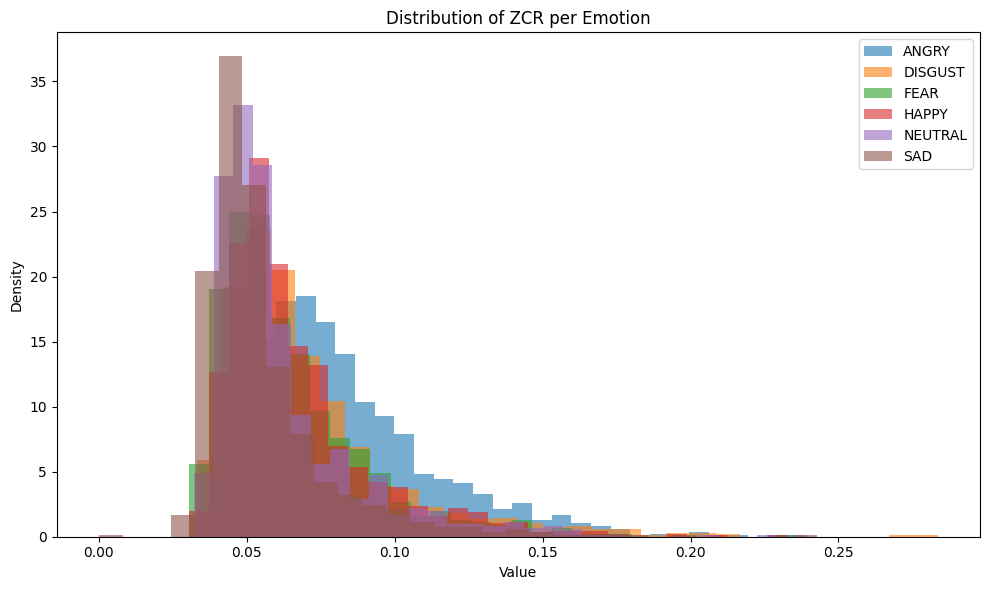

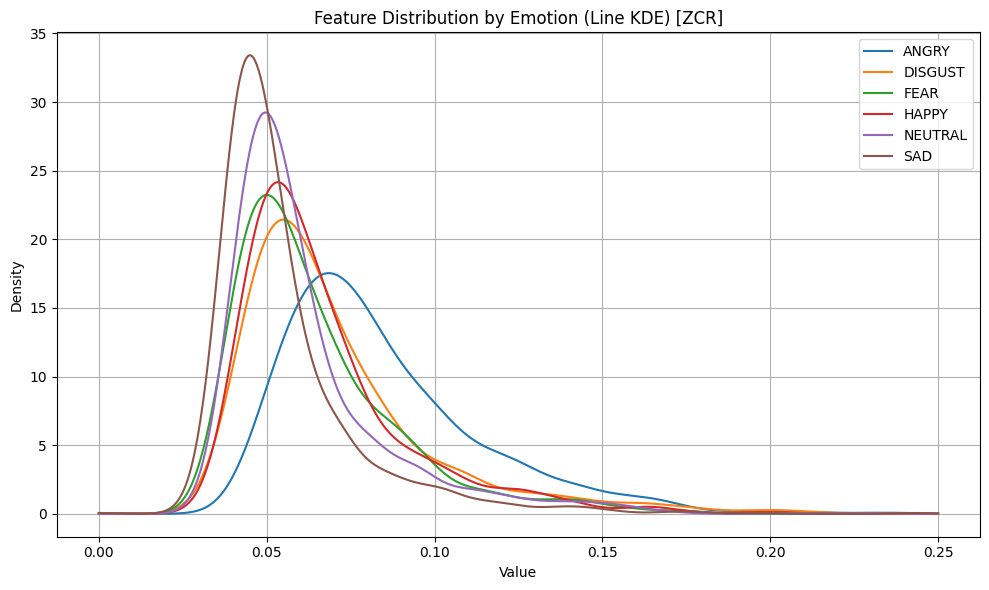

Mean and Std of ZCR per Emotion:

Emotion: ANGRY      -> Mean: 0.0846, Std: 0.0296
Emotion: DISGUST    -> Mean: 0.0708, Std: 0.0300
Emotion: FEAR       -> Mean: 0.0645, Std: 0.0249
Emotion: HAPPY      -> Mean: 0.0671, Std: 0.0255
Emotion: NEUTRAL    -> Mean: 0.0619, Std: 0.0244
Emotion: SAD        -> Mean: 0.0553, Std: 0.0218


In [36]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

emotions = ["ANGRY", "DISGUST", "FEAR", "HAPPY", "NEUTRAL", "SAD"]
zcr_stats = {}

# Histogram Plot
plt.figure(figsize=(10, 6))
for emo in emotions:
    values = Dataset[f"{emo}"]["zcr"]
    plt.hist(values, bins=30, alpha=0.6, label=emo, density=True)

    # Compute and store stats
    zcr_stats[emo] = {
        'mean': np.mean(values),
        'std': np.std(values)
    }

plt.title("Distribution of ZCR per Emotion")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# KDE Plot
x_vals = np.linspace(0, 0.25, 1000)
plt.figure(figsize=(10, 6))
for emo in emotions:
    values = Dataset[f"{emo}"]["zcr"]
    kde = gaussian_kde(values)
    plt.plot(x_vals, kde(x_vals), label=emo)

plt.title("Feature Distribution by Emotion (Line KDE) [ZCR]")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Print mean and std per emotion for ZCR
print("Mean and Std of ZCR per Emotion:\n")
for emo in emotions:
    mean = zcr_stats[emo]['mean']
    std = zcr_stats[emo]['std']
    print(f"Emotion: {emo:10s} -> Mean: {mean:.4f}, Std: {std:.4f}")


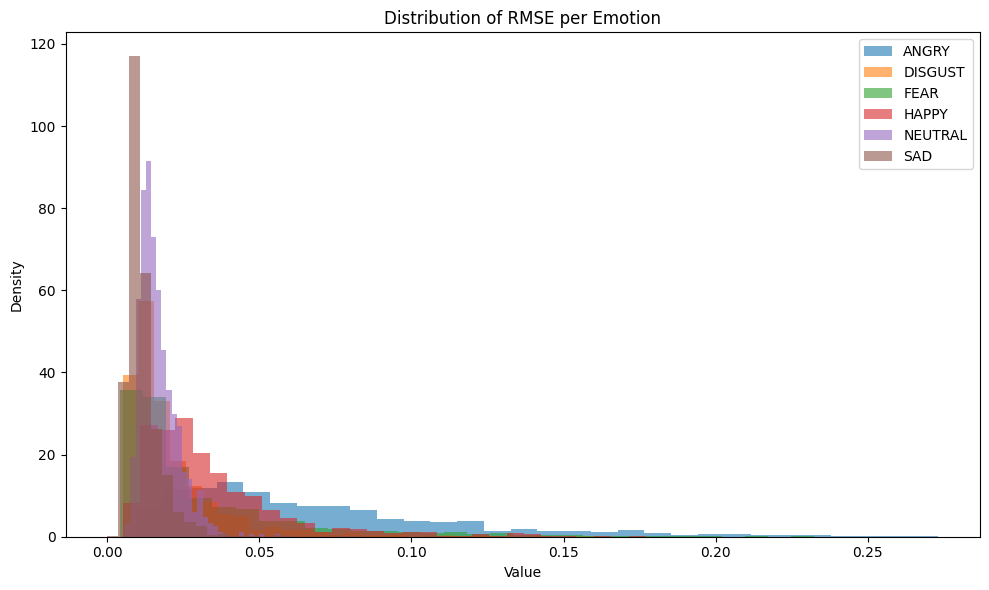

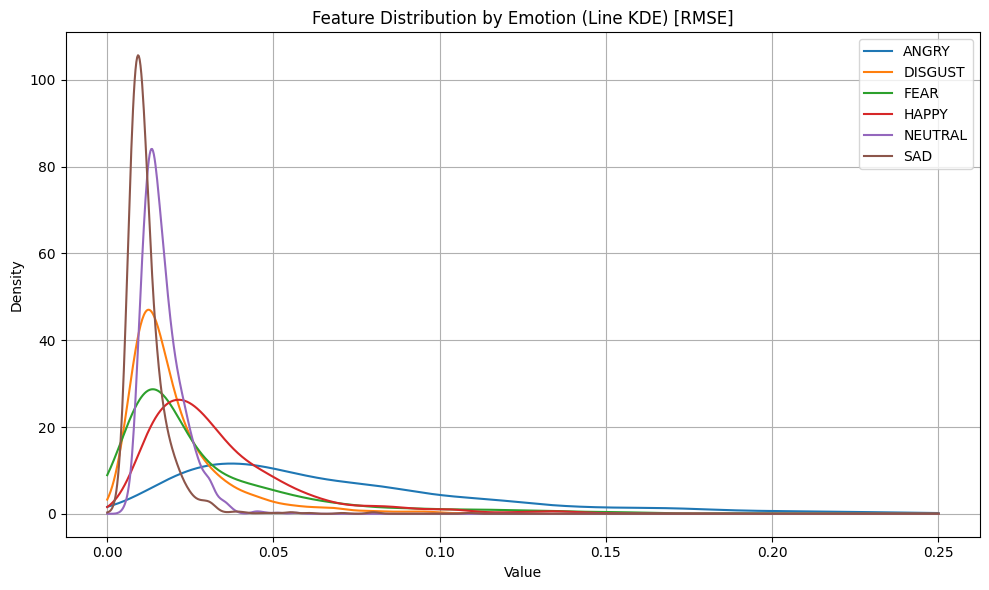

Mean and Std of RMSE per Emotion:

Emotion: ANGRY      -> Mean: 0.0692, Std: 0.0478
Emotion: DISGUST    -> Mean: 0.0212, Std: 0.0174
Emotion: FEAR       -> Mean: 0.0303, Std: 0.0310
Emotion: HAPPY      -> Mean: 0.0340, Std: 0.0235
Emotion: NEUTRAL    -> Mean: 0.0167, Std: 0.0062
Emotion: SAD        -> Mean: 0.0120, Std: 0.0071


In [35]:
# Histogram plot
plt.figure(figsize=(10, 6))
rmse_stats = {}  # Store stats for each emotion

for emo in emotions:
    values = Dataset[f"{emo}"]["rmse"]
    plt.hist(values, bins=30, alpha=0.6, label=emo, density=True)

    # Compute and store stats
    rmse_stats[emo] = {
        'mean': np.mean(values),
        'std': np.std(values)
    }

plt.title("Distribution of RMSE per Emotion")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# KDE plot
x_vals = np.linspace(0, 0.25, 1000)
plt.figure(figsize=(10, 6))
for emo in emotions:
    values = Dataset[f"{emo}"]["rmse"]
    kde = gaussian_kde(values)
    plt.plot(x_vals, kde(x_vals), label=emo)

plt.title("Feature Distribution by Emotion (Line KDE) [RMSE]")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Print mean and std per emotion for RMSE
print("Mean and Std of RMSE per Emotion:\n")
for emo in emotions:
    mean = rmse_stats[emo]['mean']
    std = rmse_stats[emo]['std']
    print(f"Emotion: {emo:10s} -> Mean: {mean:.4f}, Std: {std:.4f}")


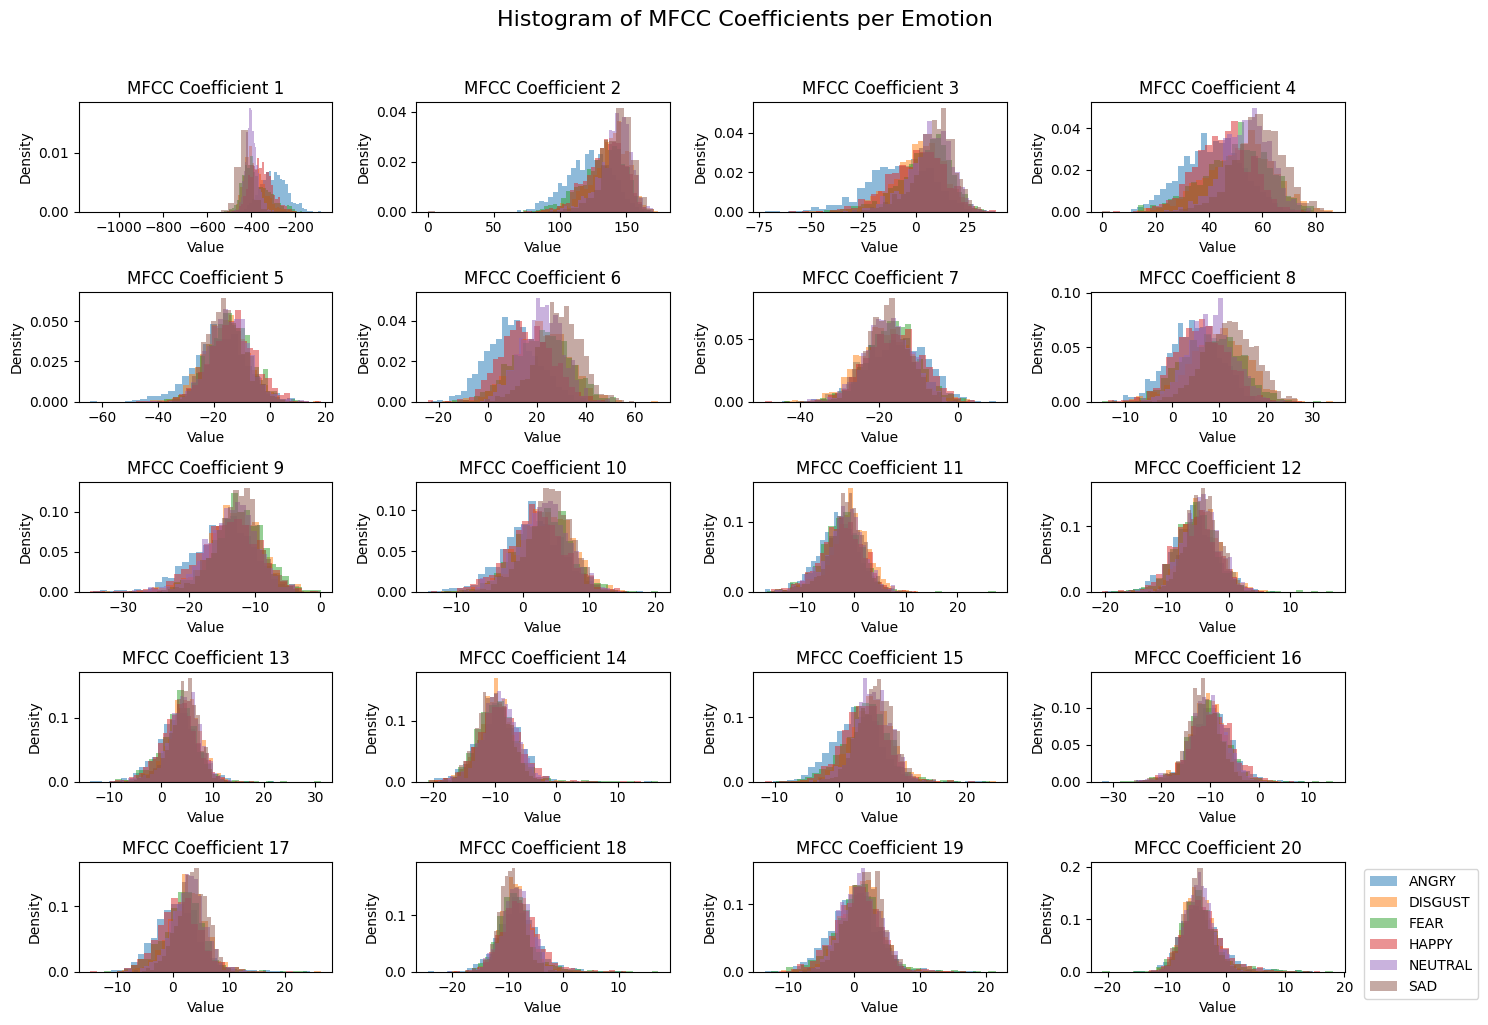

In [25]:
plt.figure(figsize=(15, 10))
for i in range(20):  # Assuming 20 MFCC arrays per emotion
    plt.subplot(5, 4, i + 1)
    for emo in emotions:
        # Extract the i-th MFCC array from each emotion and flatten if needed
        values = [sample[i] for sample in Dataset[f"{emo}"]["mfcc"]]
        plt.hist(values, bins=30, alpha=0.5, label=emo, density=True)
    
    plt.title(f"MFCC Coefficient {i+1}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle("Histogram of MFCC Coefficients per Emotion", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


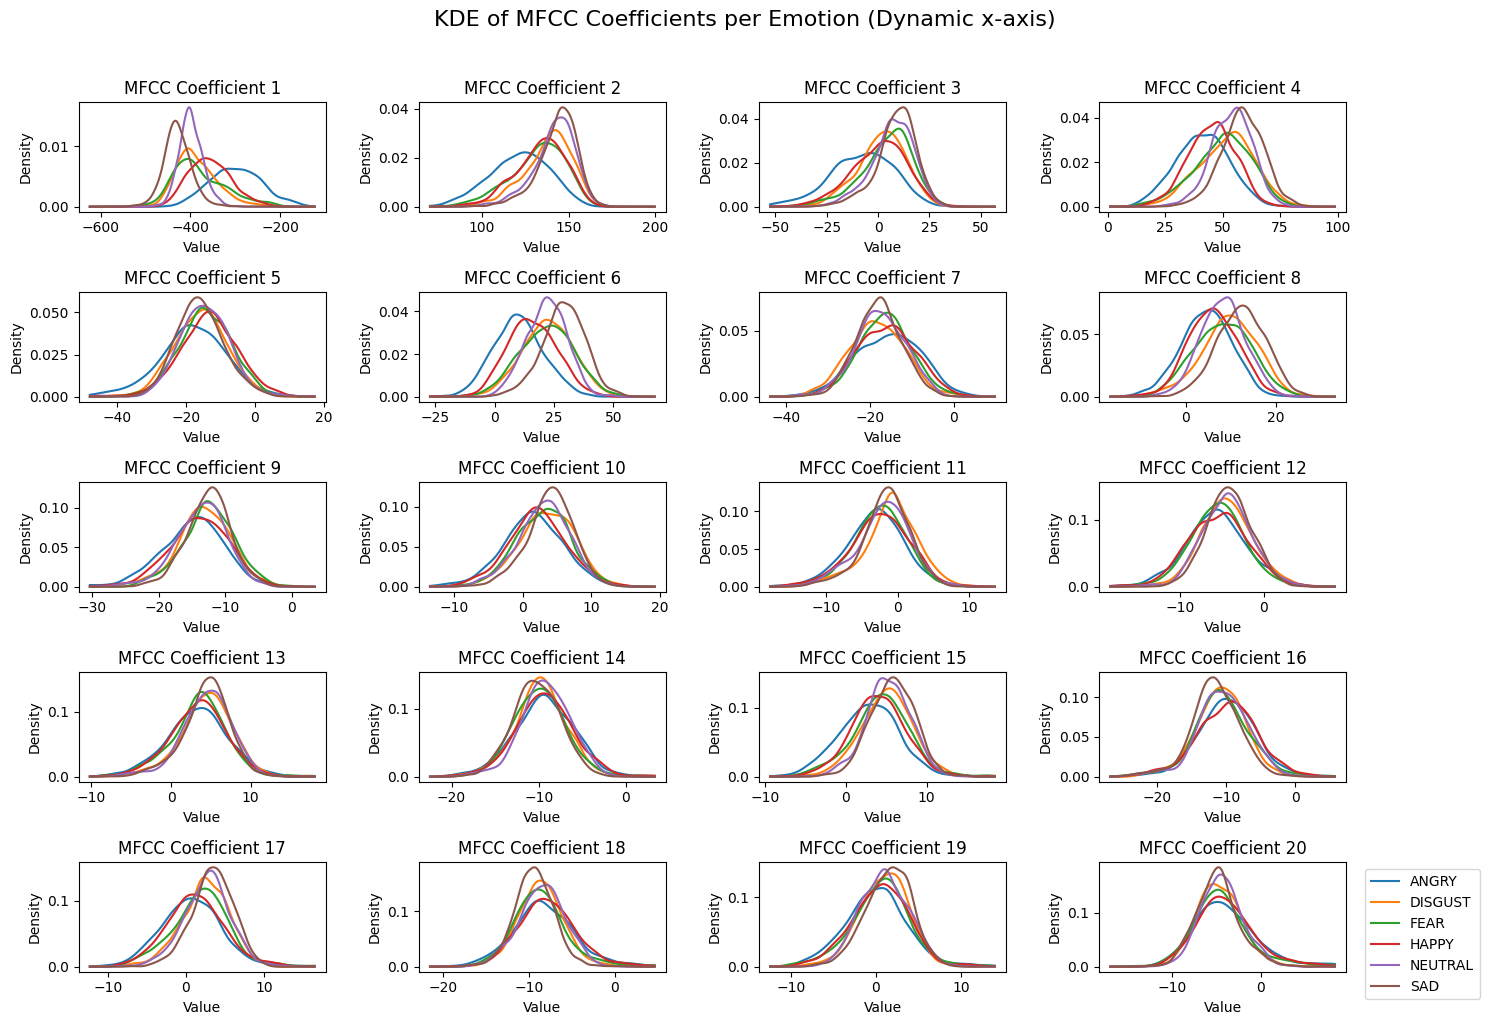

Mean and Std per Emotion per MFCC Coefficient:

Emotion: ANGRY
  MFCC  1 -> Mean: -298.124, Std: 57.716
  MFCC  2 -> Mean: 121.593, Std: 17.098
  MFCC  3 -> Mean: -7.995, Std: 15.712
  MFCC  4 -> Mean: 41.206, Std: 11.359
  MFCC  5 -> Mean: -17.941, Std: 9.764
  MFCC  6 -> Mean: 9.999, Std: 10.442
  MFCC  7 -> Mean: -15.744, Std: 7.793
  MFCC  8 -> Mean: 4.588, Std: 5.566
  MFCC  9 -> Mean: -15.002, Std: 4.787
  MFCC 10 -> Mean: 1.481, Std: 4.461
  MFCC 11 -> Mean: -3.137, Std: 4.062
  MFCC 12 -> Mean: -5.640, Std: 3.706
  MFCC 13 -> Mean: 3.305, Std: 3.975
  MFCC 14 -> Mean: -9.326, Std: 3.546
  MFCC 15 -> Mean: 2.893, Std: 3.853
  MFCC 16 -> Mean: -9.847, Std: 4.285
  MFCC 17 -> Mean: 0.812, Std: 4.058
  MFCC 18 -> Mean: -8.127, Std: 3.810
  MFCC 19 -> Mean: 0.116, Std: 3.839
  MFCC 20 -> Mean: -3.868, Std: 3.803

Emotion: DISGUST
  MFCC  1 -> Mean: -385.598, Std: 46.325
  MFCC  2 -> Mean: 137.840, Std: 14.257
  MFCC  3 -> Mean: 1.608, Std: 11.958
  MFCC  4 -> Mean: 51.619, Std: 12.1

In [34]:
plt.figure(figsize=(15, 10))
emotion_stats = {}  # Store stats for printing

for i in range(20):
    plt.subplot(5, 4, i + 1)

    # Collect all values for the i-th MFCC coefficient across all emotions for x-range
    all_values = []
    for emo in emotions:
        values = [sample[i] for sample in Dataset[f"{emo}"]["mfcc"]]
        all_values.extend(values)

    mean_all = np.mean(all_values)
    std_all = np.std(all_values)
    x_vals = np.linspace(mean_all - 4*std_all, mean_all + 4*std_all, 1000)

    for emo in emotions:
        values = [sample[i] for sample in Dataset[f"{emo}"]["mfcc"]]
        kde = gaussian_kde(values)
        plt.plot(x_vals, kde(x_vals), label=emo)

        # Save stats
        if emo not in emotion_stats:
            emotion_stats[emo] = []
        emotion_stats[emo].append({
            'mean': np.mean(values),
            'std': np.std(values)
        })

    plt.title(f"MFCC Coefficient {i+1}")
    plt.xlabel("Value")
    plt.ylabel("Density")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle("KDE of MFCC Coefficients per Emotion (Dynamic x-axis)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ✅ Print mean and std per emotion per MFCC coefficient
print("Mean and Std per Emotion per MFCC Coefficient:\n")
for emo in emotions:
    print(f"Emotion: {emo}")
    for i, stats in enumerate(emotion_stats[emo]):
        print(f"  MFCC {i+1:2d} -> Mean: {stats['mean']:.3f}, Std: {stats['std']:.3f}")
    print()


In [26]:
# plt.figure(figsize=(10, 6))
# for emo in emotions:
#     plt.hist(Dataset[f"{emo}"]["mfcc"], bins = 30, alpha = 0.6, label = emo, density = True)

# plt.title("Distribution of MFCC per Emotions")
# plt.xlabel("Value")
# plt.ylabel("Density")
# plt.legend()
# plt.tight_layout()
# plt.show()

# x_vals = np.linspace(-20, 0, 1000)
# plt.figure(figsize=(10, 6))
# for emo in emotions:
#     kde = gaussian_kde(Dataset[f"{emo}"]["mfcc"])
#     plt.plot(x_vals, kde(x_vals), label = emo)

# plt.title("Feature Distribution by Emotion (Line KDE) [MFCC]")
# plt.xlabel("Value")
# plt.ylabel("Density")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

### Make a 2D plot

In [27]:
# # Accumulate plot data
# emotion_colors = {
#     "ANGRY": "red",
#     "DISGUST": "green",
#     "FEAR": "blue",
#     "HAPPY": "orange",
#     "NEUTRAL": "purple",
#     "SAD": "gray",
# }
# zcr_all, mfcc_all, rmse_all, colors = [], [], [], []

# for emotion, features in Dataset.items():
#     for zcr, rmse, mfcc in zip(features["zcr"], features["rmse"], features["mfcc"]):
#         zcr_val = np.mean(zcr)
#         rmse_val = np.mean(rmse)
#         mfcc_val = np.mean(mfcc)

#         zcr_all.append(zcr_val)
#         rmse_all.append(rmse_val)
#         mfcc_all.append(mfcc_val)
#         colors.append(emotion_colors[emotion])

# # Normalize RMSE for point size
# rmse_all = np.array(rmse_all)
# sizes = 100 * (rmse_all - rmse_all.min()) / (rmse_all.max() - rmse_all.min()) + 10

# # Plot
# plt.figure(figsize=(10, 6))
# plt.scatter(zcr_all, mfcc_all, s=sizes, c=colors, alpha=0.7, edgecolors='black', linewidth=0.5)

# plt.xlabel("Mean ZCR")
# plt.ylabel("Mean MFCC")
# plt.title("ZCR vs MFCC (RMSE as Point Size)")

# # Legend
# handles = [plt.Line2D([], [], marker='o', linestyle='', color=color, label=emotion)
#            for emotion, color in emotion_colors.items()]
# plt.legend(handles=handles, title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [28]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import numpy as np


# # Color map
# emotion_colors = {
#     "ANGRY": "red",
#     "DISGUST": "green",
#     "FEAR": "blue",
#     "HAPPY": "orange",
#     "NEUTRAL": "purple",
#     "SAD": "gray",
#     "SURPRISE": "cyan"
# }

# # Collect data
# zcr_all, mfcc_all, rmse_all, colors = [], [], [], []

# for emotion, features in Dataset.items():
#     for zcr, rmse, mfcc in zip(features["zcr"], features["rmse"], features["mfcc"]):
#         zcr_val = np.mean(zcr)
#         rmse_val = np.mean(rmse)
#         mfcc_val = np.mean(mfcc)

#         zcr_all.append(zcr_val)
#         rmse_all.append(rmse_val)
#         mfcc_all.append(mfcc_val)
#         colors.append(emotion_colors[emotion])

# # Plot
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# scatter = ax.scatter(zcr_all, mfcc_all, rmse_all, c=colors, s=50, edgecolors='black', alpha=0.8)

# ax.set_xlabel("Mean ZCR")
# ax.set_ylabel("Mean MFCC")
# ax.set_zlabel("Mean RMSE")
# ax.set_title("3D Feature Scatter Plot")

# # Legend
# handles = [plt.Line2D([], [], marker='o', linestyle='', color=color, label=emotion)
#            for emotion, color in emotion_colors.items()]
# ax.legend(handles=handles, title="Emotion", loc='upper right')

# plt.tight_layout()
# plt.show()


In [29]:
# import plotly.express as px
# import numpy as np
# import pandas as pd

# # Example data generation (remove if using real data)
# for emotion in Dataset:
#     for _ in range(10):
#         Dataset[emotion]["zcr"].append(np.random.rand(20))
#         Dataset[emotion]["rmse"].append(np.random.rand(20))
#         Dataset[emotion]["mfcc"].append(np.random.rand(13))

# # Convert to DataFrame for Plotly
# rows = []
# for emotion, features in Dataset.items():
#     for zcr, rmse, mfcc in zip(features["zcr"], features["rmse"], features["mfcc"]):
#         rows.append({
#             "Emotion": emotion,
#             "ZCR": np.mean(zcr),
#             "RMSE": np.mean(rmse),
#             "MFCC": np.mean(mfcc)
#         })

# df = pd.DataFrame(rows)

# # Plotly 3D scatter plot
# fig = px.scatter_3d(
#     df,
#     x="ZCR", y="MFCC", z="RMSE",
#     color="Emotion",
#     symbol="Emotion",
#     size_max=18,
#     title="Interactive 3D Plot of Features",
#     labels={"ZCR": "Mean ZCR", "MFCC": "Mean MFCC", "RMSE": "Mean RMSE"},
#     hover_data=["Emotion"]
# )

# fig.update_traces(marker=dict(size=6))
# fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
# fig.show()


## Make the Activation Map